In [27]:
import pandas as pd
data = {
    "Size":[800, 1000, 1200, 1500, 1800],
    "Location": ["Rural", "Urban", "Rural", "Urban", "Urban"],
    "Price": [30,50,42,72,85]
}

In [28]:
data

{'Size': [800, 1000, 1200, 1500, 1800],
 'Location': ['Rural', 'Urban', 'Rural', 'Urban', 'Urban'],
 'Price': [30, 50, 42, 72, 85]}

In [29]:
df = pd.DataFrame(data)
df_encoded = pd.get_dummies(
    df,
    columns=["Location"],
    drop_first = True,
    dtype = int
)
print(df_encoded)

   Size  Price  Location_Urban
0   800     30               0
1  1000     50               1
2  1200     42               0
3  1500     72               1
4  1800     85               1


In [30]:
X = df_encoded[["Size", "Location_Urban"]]
y = df_encoded["Price"]

print("X:")
print(X)

print("\ny:")
print(y)

X:
   Size  Location_Urban
0   800               0
1  1000               1
2  1200               0
3  1500               1
4  1800               1

y:
0    30
1    50
2    42
3    72
4    85
Name: Price, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression


# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict prices for test data
y_pred = model.predict(X_test)

In [33]:
print("Actaual price:",y_test.values)
print("predicted Values: ",y_pred)

Actaual price: [50]
predicted Values:  [55.88]


In [34]:
print("Intercept:", model.intercept_)

Intercept: 1.200000000000017


In [35]:
print("Coefficients:", model.coef_)

Coefficients: [ 0.0348 19.88  ]


Multiple Linear Regression uses:

 y = b_0 + b_1x_1 + b_2x_2 

For your dataset:

 Price = b_0 + b_1(Size) + b_2(Location_Urban) 

Where:

b_0 = intercept
b_1 = coefficient of Size
b_2 = coefficient of Location

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 34.57440000000011
R2 Score: nan


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


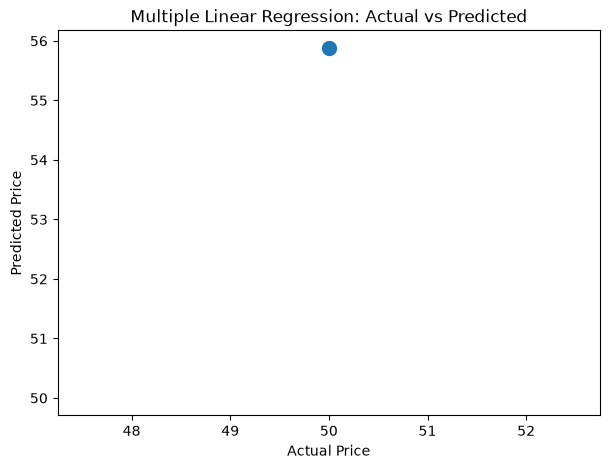

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Actual vs Predicted
plt.scatter(y_test, y_pred, s=100)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()

Ridge is basically Linear Regression + L2 regularization

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV

In [ ]:
#Ridge regression with the alpha value = 1

model_ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)

print("Actual Price:", y_test.values)
print("Predicted Price:", y_pred_ridge)

Actual Price: [50]
Predicted Price: [57.57190545]


In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    model_ridge = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    model_ridge.fit(X_train, y_train)

    y_pred_ridge = model_ridge.predict(X_test)

    print("Alpha:", alpha)
    print("Predicted Price:", y_pred_ridge)
    print()
    

Alpha: 0.01
Predicted Price: [55.93371272]

Alpha: 0.1
Predicted Price: [56.33204504]

Alpha: 1
Predicted Price: [57.57190545]

Alpha: 10
Predicted Price: [57.71703133]

Alpha: 100
Predicted Price: [57.33356044]



In [ ]:
ridge_cv_model = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=4
)

model_ridge_cv = make_pipeline(
    StandardScaler(),
    ridge_cv_model
)

model_ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv_model.alpha_)

Best alpha: 0.01


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\sit